Index(['ram_percent', 'net_bytes_per_sec', 'cpu_roll_mean', 'ram_roll_mean',
       'net_roll_mean', 'cpu_change', 'ram_change', 'net_change', 'hour',
       'minute'],
      dtype='str')
Random Forest Results
MAE: 0.02687896747409706
RMSE: 0.04340669014680451
Approx Accuracy: 75.63927733499287


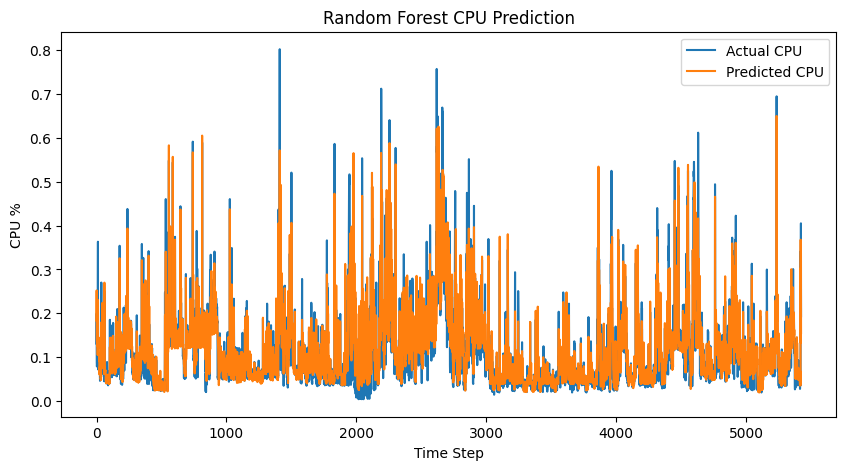

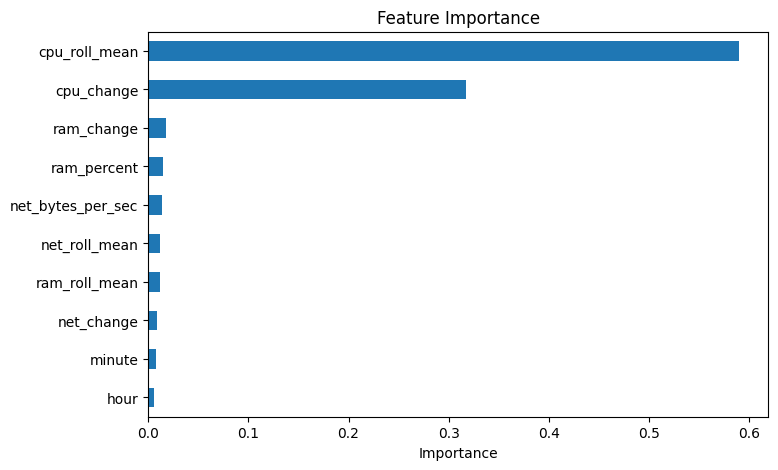

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------
# 1 Load Training and Testing Data
# -----------------------------------
train_data = pd.read_csv("../data/train_data.csv")
test_data = pd.read_csv("../data/test_data.csv")


# -----------------------------------
# 2 Define Features and Target
# Predict CPU usage
# -----------------------------------
X_train = train_data.drop(columns=["cpu_percent"])
y_train = train_data["cpu_percent"]

X_test = test_data.drop(columns=["cpu_percent"])
y_test = test_data["cpu_percent"]
print(X_train.columns)
# -----------------------------------
# 3 Train Random Forest Model
# -----------------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# -----------------------------------
# 4 Make Predictions
# -----------------------------------
y_pred = rf_model.predict(X_test)

# -----------------------------------
# 5 Evaluate Model
# -----------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)

avg_cpu = y_test.mean()

accuracy = 100 - (mae / avg_cpu * 100)

print("Approx Accuracy:", accuracy)

# -----------------------------------
# 6 Plot Predictions
# -----------------------------------
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual CPU")
plt.plot(y_pred, label="Predicted CPU")

plt.title("Random Forest CPU Prediction")
plt.xlabel("Time Step")
plt.ylabel("CPU %")

plt.legend()
plt.show()

# -----------------------------------
# 7 Feature Importance
# -----------------------------------
importance = rf_model.feature_importances_

feature_importance = pd.Series(importance, index=X_train.columns)

plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()